In [118]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import miceforest as mf

## 1) Scraping GICS from Wikipedia:

Scraping from wikipedia the GICS Sector info and saving it to an excel file:

In [119]:
# url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# response = requests.get(url)
# soup = BeautifulSoup(response.text, 'html.parser')
# table = soup.find('tbody')
# data = []
# rows = table.find_all('tr')
# for row in rows:
#   cells = row.find_all('td')
#   row_data = [cell.get_text(strip=True) for cell in cells]
#   data.append(row_data)

# symbol_wiki = pd.DataFrame(data)
# columns = ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date Added', 'CIK', 'Founded']
# symbol_wiki.columns = columns
# symbol_wiki = symbol_wiki.iloc[1:]
# #print(symbol_wiki.head())
#symbol_wiki.to_excel("Data/symbol_wiki.xlsx", index = False)

Load the excel file with the GICS Sector information associated to the Symbol:

In [120]:
symbol_wiki = pd.read_excel("Data/symbol_wiki.xlsx")

In [121]:
symbol_wiki.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date Added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


Read the dataset with the symbol for each company of the S&P 500 (composition of december 2022) from LSEG Workspace, to match it with GICS data from wikipedia:

In [122]:
type_lseg = pd.read_excel("Data/out-of-sample/symbol_comp_0922.xlsm", sheet_name="SYMBOL", dtype=str).iloc[0].values[1:]
symbol_lseg = pd.read_excel("Data/out-of-sample/symbol_comp_0922.xlsm", sheet_name="SYMBOL", dtype=str, header=2)
symbol_lseg = symbol_lseg.iloc[:1].transpose().reset_index().rename(columns= {"index": "NAME", 0: "SYMBOL"}).iloc[1:]
symbol_lseg['TYPE'] = type_lseg
gics = pd.merge(symbol_lseg, symbol_wiki[['Symbol', 'GICS Sector']], how = 'left', left_on = 'SYMBOL', right_on='Symbol')

In [123]:
symbol_lseg_old = pd.read_excel("Data/out-of-sample/symbol_comp_1221.xlsm", sheet_name="SYMBOL", dtype=str, header=2)

symbol_lseg_old = symbol_lseg_old.iloc[:1].transpose().reset_index().rename(columns= {"index": "NAME", 0: "SYMBOL"}).iloc[1:]

In [124]:
symbol_lseg_old

,NAME,SYMBOL
1,AMAZON.COM,AMZN
2,ABBOTT LABORATORIES,ABT
3,AES,AES
4,ABIOMED DEAD - DELIST.23/12/22,ABMD
5,INTERNATIONAL BUS.MCHS.,IBM
...,...,...
501,WEC ENERGY GROUP,WEC
502,MONSTER BEVERAGE,MNST
503,LINDE (NYS),LIN
504,SBA COMMS.,SBAC


In [125]:
set(symbol_lseg['SYMBOL']) - set(symbol_lseg_old['SYMBOL'])

{'CEG', 'CPT', 'CSGP', 'INVH', 'KDP', 'MOH', 'NDSN', 'ON', 'VICI'}

In [126]:
set(symbol_lseg_old['SYMBOL']) - set(symbol_lseg['SYMBOL'])

{'CERN', 'GAP', 'INFO', 'IPGP', 'PBCT', 'PENN', 'PVH', 'UAA', 'XLNX'}

In [127]:
gics.head()

,NAME,SYMBOL,TYPE,Symbol,GICS Sector
0,AMAZON.COM,AMZN,891399,AMZN,Consumer Discretionary
1,ABBOTT LABORATORIES,ABT,916328,ABT,Health Care
2,AES,AES,545101,AES,Utilities
3,ABIOMED DEAD - DELIST.23/12/22,ABMD,777953,NaN,NaN
4,INTERNATIONAL BUS.MCHS.,IBM,906187,IBM,Information Technology


In [128]:
gics.loc[gics['SYMBOL'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


## 2) Fill the missing GICS values manually from online sources:

In [129]:
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ROBERT HALF"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ALASKA AIR GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "AMERICAN AIRLINES GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BIO-RAD LABORATORIES 'A'"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TELEFLEX"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ILLUMINA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CATALENT DEAD - DELIST.18/12/24"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DENTSPLY SIRONA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ORGANON"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ETSY"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BORGWARNER"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "V F"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WHIRLPOOL"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BATH AND BODY WORKS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ADV.AUTO PARTS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WESTROCK DEAD - DELIST.08/07/24"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CELANESE"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FMC"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SEALED AIR"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PIONEER NTRL.RES. DEAD - DELIST.03/05/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "MARATHON OIL DEAD - DELIST.22/11/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ZIONS BANCORP."), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "COMERICA"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISCOVER FINANCIAL SVS. DEAD - DELIST.19/05/25"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LINCOLN NATIONAL"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SVB FINANCIAL GROUP DEAD - DELIST.08/11/24"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SIGNATURE BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FIRST REPUBLIC BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "QORVO"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SOLAREDGE TECHNOLOGIES"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DXC TECHNOLOGY"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISH NETWORK 'A' DEAD - DELIST.02/01/24"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ACTIVISION BLIZZARD DEAD - DELIST.16/10/23"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LUMEN TECHNOLOGIES"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NEWELL BRANDS (XSC)"), 'GICS Sector'] = 'Consumer Staples'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "VORNADO REALTY TRUST"), 'GICS Sector'] = 'Real Estate'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ABIOMED DEAD - DELIST.23/12/22"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CITRIX SYS. DEAD - DELIST.03/10/22"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CERNER DEAD - DELIST.09/06/22"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DUKE REALTY DEAD - DELIST.03/10/22"), 'GICS Sector'] = 'Real Estate'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "GAP"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PENN ENTERTAINMENT"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "IPG PHOTONICS"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "XILINX DEAD - DELIST.15/02/22"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "UNDER ARMOUR A"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "UNDER ARMOUR 'C'"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PEOPLES UNITED FINANCIAL DEAD - DELIST.05/04/22"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FORTUNE BRANDS INNOVATIONS"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "IHS MARKIT DEAD - DELIST.28/02/22"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PVH"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TWITTER DEAD - DELIST.28/10/22"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PARAMOUNT SKYDANCE B"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NIELSEN DEAD - DELIST.12/10/22"), 'GICS Sector'] = 'Industrials'

In [130]:
gics.loc[(gics['GICS Sector'].isna())]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


In [131]:
gics.groupby(['GICS Sector'])['NAME'].count()

GICS Sector
Communication Services    26
Consumer Discretionary    52
Consumer Staples          37
Energy                    21
Financials                74
Health Care               64
Industrials               76
Information Technology    63
Materials                 28
Real Estate               33
Utilities                 29
Name: NAME, dtype: int64

Change the Symbol of BERKSHIRE HATHAWAY 'B' from BRK.A to BRK-B as it is the correct symbol:

In [132]:
gics.loc[(gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'SYMBOL'] = 'BRK-B' 

## 3) Calculate the weights within sector, using adjusted close price for corporate splits and Free Float Number of Shares Outstanding

the weights are calculated as of the last market trading day of 2022.

Taking the last day of 2022 closing prices adjusted for corporate splits (from LSEG):

In [133]:
price = pd.read_excel("Data/out-of-sample/price_div_comp_0922.xlsm", sheet_name="CLOSE PRICE", header=3)
price = price.iloc[1:]
price = price.transpose()
price.columns = price.iloc[0]
price = price.iloc[1:]



# Convert column labels to datetime
price.columns = pd.to_datetime(price.columns, errors="coerce")

# Select the last trading day of 2021
price = price.loc[:, price.columns <= "2022-09-30"].iloc[:, -1]
print(price)
price.name = "Price last day Sep 22"



AMAZON.COM                             113
ABBOTT LABORATORIES                  96.76
AES                                   22.6
ABIOMED DEAD - DELIST.23/12/22      245.66
INTERNATIONAL BUS.MCHS.             118.81
                                    ...   
WEC ENERGY GROUP                     89.43
MONSTER BEVERAGE                     43.48
LINDE (NYS)                       269.5901
SBA COMMS.                        284.6499
CHARTER COMMS.CL.A                303.3501
Name: 2022-09-30 00:00:00, Length: 503, dtype: object


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [134]:
price.head()

AMAZON.COM                           113
ABBOTT LABORATORIES                96.76
AES                                 22.6
ABIOMED DEAD - DELIST.23/12/22    245.66
INTERNATIONAL BUS.MCHS.           118.81
Name: Price last day Sep 22, dtype: object

Taking the last day of 2022 free float number of shares outstanding adjusted for corporate splits (from LSEG):

In [135]:
ffnosh = pd.read_excel("Data/out-of-sample/price_div_comp_0922.xlsm", sheet_name="FFNOSH", header=3)
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh.transpose()
ffnosh.columns = ffnosh.iloc[0]
ffnosh = ffnosh.iloc[1:]
# Convert column labels to datetime
ffnosh.columns = pd.to_datetime(ffnosh.columns, errors="coerce")

# Select the last trading day of 2021
ffnosh= ffnosh.loc[:, ffnosh.columns <= "2022-09-30"].iloc[:, -1]

ffnosh.name = "ffnosh last day Sep 22"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [136]:
ffnosh.index = ffnosh.index.str.replace(' - DS FREE FLOAT SHRE', '', regex=False)

In [137]:
ffnosh.head()

AMAZON.COM                        8504439
ABBOTT LABORATORIES               1743574
AES                                538382
ABIOMED DEAD - DELIST.23/12/22      39185
INTERNATIONAL BUS.MCHS.            776410
Name: ffnosh last day Sep 22, dtype: object

In [138]:
ffnosh = pd.DataFrame(ffnosh)
price = pd.DataFrame(price)

In [139]:
gics = pd.merge(gics, ffnosh, how = 'left', left_on = 'NAME', right_index=True)

In [140]:
gics = pd.merge(gics, price, how = 'left', left_on = 'NAME', right_index=True)

Checking for nans:

In [141]:
gics.loc[gics['Price last day Sep 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22


In [142]:
gics.loc[gics['ffnosh last day Sep 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22


In [143]:
gics = gics.loc[: , ['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day Sep 22', 'Price last day Sep 22']]

Calculating weights within sector:

In [144]:
# STEP 1: Group by SYMBOL to combine share classes -> in this way duplicates such as NWSA, FOXA, GOOGL are counted as one weight (bc their emissions are reported at the parent company level)
aggregated = gics.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day Sep 22'].sum(),
        'Weighted Price': (df['ffnosh last day Sep 22'] * df['Price last day Sep 22']).sum() / df['ffnosh last day Sep 22'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/3436041431.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics.groupby('SYMBOL').apply(


NB:

Free float = the number of shares available for trading in the market.

Excludes shares held by:

Founders

Governments

Strategic long-term investors (who won’t sell in the market)

In [145]:
gics[gics['SYMBOL'].duplicated(keep=False)]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22
410,NEWS 'A',89257H,NWSA,Communication Services,295387,15.11
411,NEWS 'B',89257J,NWSA,Communication Services,97820,15.42
435,FOX A,9406MC,FOXA,Communication Services,280586,30.68
436,FOX B,9406MA,FOXA,Communication Services,145492,28.5
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5503682,95.65
497,ALPHABET 'C',871997,GOOGL,Communication Services,5346878,96.15


In [146]:
pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE').loc[pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE')['SYMBOL'].isin(['GOOGL', 'NWSA', 'FOXA'])]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap
410,NEWS 'A',89257H,NWSA,Communication Services,295387,15.11,0.002599,5.971682e+06
411,NEWS 'B',89257J,NWSA,Communication Services,97820,15.42,NaN,NaN
435,FOX A,9406MC,FOXA,Communication Services,280586,30.68,0.005550,1.275490e+07
436,FOX B,9406MA,FOXA,Communication Services,145492,28.5,NaN,NaN
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5503682,95.65,0.452789,1.040530e+09
497,ALPHABET 'C',871997,GOOGL,Communication Services,5346878,96.15,NaN,NaN


After grouping by SYMBOL, each company has one weight_in_sector. When merging back, only one of the share classes (TYPE) keeps the weight, the other appears as NaN. This avoids double-counting and I can therefore merge on Type:

In [147]:
gics = pd.merge(gics, aggregated[['TYPE', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'TYPE', right_on = 'TYPE') 

In [148]:
gics.loc[gics['SYMBOL'].isin(['GOOGL', 'NWSA', 'FOXA'])]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap
410,NEWS 'A',89257H,NWSA,Communication Services,295387,15.11,0.002599,5.971682e+06
411,NEWS 'B',89257J,NWSA,Communication Services,97820,15.42,NaN,NaN
435,FOX A,9406MC,FOXA,Communication Services,280586,30.68,0.005550,1.275490e+07
436,FOX B,9406MA,FOXA,Communication Services,145492,28.5,NaN,NaN
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5503682,95.65,0.452789,1.040530e+09
497,ALPHABET 'C',871997,GOOGL,Communication Services,5346878,96.15,NaN,NaN


In [149]:
gics.loc[gics['GICS Sector'] == 'Communication Services']['weight_in_sector'].sum()

1.0000000000000002

In [150]:
gics.loc[gics['GICS Sector'] == 'Consumer Discretionary']['weight_in_sector'].sum()

1.0

In [151]:
len(gics)

503

In [152]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 4) Read and merge scope emissions data

In [153]:
scope_emission_1  = pd.read_excel("Data/out-of-sample/carbon_int_comp_0922.xlsm", sheet_name="SCOPE 1", header=4).iloc[107]
#print(scope_emission_1)
scope_emission_1.index = scope_emission_1.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_1 = pd.DataFrame(scope_emission_1)
scope_emission_1.columns = ['Scope 1']
scope_emission_1 = scope_emission_1.iloc[1:]
scope_emission_1.index.name = 'Type'

scope_emission_2  = pd.read_excel("Data/out-of-sample/carbon_int_comp_0922.xlsm", sheet_name="SCOPE 2", header=4).iloc[107]
scope_emission_2.index = scope_emission_2.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_2 = pd.DataFrame(scope_emission_2)
scope_emission_2.columns = ['Scope 2']
scope_emission_2 = scope_emission_2.iloc[1:]
scope_emission_2.index.name = 'Type'

scope_emission_3  = pd.read_excel("Data/out-of-sample/carbon_int_comp_0922.xlsm", sheet_name="SCOPE 3", header=4).iloc[107]
scope_emission_3.index = scope_emission_3.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_3 = pd.DataFrame(scope_emission_3)
scope_emission_3.columns = ['Scope 3']
scope_emission_3 = scope_emission_3.iloc[1:]
scope_emission_3.index.name = 'Type'

In [154]:
revenue = pd.read_excel("Data/out-of-sample/carbon_int_comp_0922.xlsm", sheet_name="REVENUE", header=4).iloc[1:].iloc[107]
revenue.index = revenue.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
revenue = pd.DataFrame(revenue)
revenue.columns = ['Revenue']
revenue = revenue.iloc[1:]
revenue.index.name = 'Type'

In [155]:
gics = pd.merge(gics, scope_emission_1, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_2, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_3, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, revenue, how = 'left', left_on = 'TYPE', right_index=True)

In [156]:
gics.loc[gics['SYMBOL'].isin(['GOOGL', 'NWSA', 'FOXA', 'UAA'])]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue
410,NEWS 'A',89257H,NWSA,Communication Services,295387,15.11,0.002599,5.971682e+06,12700.0,64000.0,866960.0,9879000.0
411,NEWS 'B',89257J,NWSA,Communication Services,97820,15.42,NaN,NaN,12700.0,64000.0,866960.0,9879000.0
435,FOX A,9406MC,FOXA,Communication Services,280586,30.68,0.005550,1.275490e+07,14266.0,52944.0,11877.0,14913000.0
436,FOX B,9406MA,FOXA,Communication Services,145492,28.5,NaN,NaN,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',29026M,GOOGL,Communication Services,5503682,95.65,0.452789,1.040530e+09,91200.0,8045400.0,10034000.0,307394000.0
497,ALPHABET 'C',871997,GOOGL,Communication Services,5346878,96.15,NaN,NaN,91200.0,8045400.0,10034000.0,307394000.0


So since the Scope emissions and Revenue are reported at parent company level I can now remove the duplicates by keeping the first row:

In [157]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [158]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']

In [159]:
missing_scopes_type = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'TYPE'].values)

In [160]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'SYMBOL'].values)

In [161]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'NAME'].values)

In [162]:
len(set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values))))

33

In [163]:
scope_1_2_nan = set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values)))

In [164]:
len(scope_1_2_nan)

33

In [165]:
scope_1_2_3_nan = scope_1_2_nan.union(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

In [166]:
len(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

136

In [167]:
len(scope_1_2_3_nan)

138

In [168]:
len(missing_scopes)

30

In [169]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.260870
Consumer Discretionary    0.307692
Consumer Staples          0.189189
Energy                    0.476190
Financials                0.243243
Health Care               0.390625
Industrials               0.342105
Information Technology    0.190476
Materials                 0.142857
Real Estate               0.303030
Utilities                 0.137931
Name: count, dtype: float64

In [170]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     6
Consumer Discretionary    16
Consumer Staples           7
Energy                    10
Financials                18
Health Care               25
Industrials               26
Information Technology    12
Materials                  4
Real Estate               10
Utilities                  4
Name: count, dtype: int64

In [171]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.260870
Consumer Discretionary    0.307692
Consumer Staples          0.189189
Energy                    0.476190
Financials                0.243243
Health Care               0.390625
Industrials               0.342105
Information Technology    0.190476
Materials                 0.142857
Real Estate               0.303030
Utilities                 0.137931
Name: count, dtype: float64

In [172]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()[['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Industrials', 'Information Technology', 'Materials', 'Utilities']].sum()

79

In [173]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     6
Consumer Discretionary    16
Consumer Staples           7
Energy                    10
Financials                18
Health Care               25
Industrials               26
Information Technology    12
Materials                  4
Real Estate               10
Utilities                  4
Name: count, dtype: int64

In [174]:
# gics.loc[gics['Carbon Intensity'].isna()]

SCOPE 3 IMPUTATION

In [175]:
gics.columns

Index(['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day Sep 22',
       'Price last day Sep 22', 'weight_in_sector', 'float_mcap', 'Scope 1',
       'Scope 2', 'Scope 3', 'Revenue', 'Scope 1+2+3', 'Carbon Intensity'],
      dtype='object')

In [176]:
# Filter the DataFrame to Financials sector
financials = gics[(gics['GICS Sector'] == 'Financials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
financials['% Scope 3'] = financials['Scope 3'] / financials['Scope 1+2+3'] * 100
#print(financials['% Scope 1'].mean())
#print(financials['% Scope 2'].mean())
#print(financials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/3156623907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/3156623907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/3156623907.py:7: SettingWit

In [177]:
# Filter the DataFrame to Industrials sector
industrials = gics[(gics['GICS Sector'] == 'Industrials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 3'] = industrials['Scope 3'] / industrials['Scope 1+2+3'] * 100
#print(industrials['% Scope 1'].mean())
#print(industrials['% Scope 2'].mean())
#print(industrials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/319877813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/319877813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/319877813.py:7: Setting

- 20 manually (scraped from sust. reports) imputed scope 1 emissions (for 2 cases, I had the total scope 1+2+3)
- 19 manually (scraped from sust. reports) imputed scope 2 emissions (for 2 cases, I had the total scope 1+2+3)
- 16 manually (scraped from sust. reports) imputed scope 3 emissions (for 2 cases, I had the total scope 1+2+3)

In [178]:
anon_df = pd.read_csv("Data/anon_map.csv")
anon_map = dict(zip(anon_df['NAME'], anon_df['AnonID']))
gics['AnonID'] = gics['NAME'].map(anon_map)


In [179]:
# Load the file
data_patch = pd.read_csv("Data/scope_emissions_patch.csv", index_col=0)

# Remove NaN values and convert to nested dictionary
data_patch = {
    company: {col: val for col, val in row.items() if pd.notna(val)}
    for company, row in data_patch.iterrows()
}

In [180]:
for name, scopes in data_patch.items():
    anon_id = anon_map[name]  # random_seed 42
    for scope, value in scopes.items():
        mask = gics['AnonID'] == anon_id
        # update only if current value is NaN
        if gics.loc[mask, scope].isna().any():
            gics.loc[mask, scope] = value
            gics.loc[mask, f'Manually Imputed {scope}'] = 1

We still have:
- 19 cases where scope 1 & 2 & 3 are all nans
- 1 where only scope 2 and scope 3 is na
- 104 cases where only scope 3 is nan

In [181]:
import itertools

# Define the columns
scope_cols = ['Scope 1', 'Scope 2', 'Scope 3']

# Generate all combinations of True (NaN) and False (not NaN)
combinations = list(itertools.product([True, False], repeat=3))

# Loop through each combination and filter the DataFrame
for comb in combinations:
    condition = (
        (gics['Scope 1'].isna() if comb[0] else gics['Scope 1'].notna()) &
        (gics['Scope 2'].isna() if comb[1] else gics['Scope 2'].notna()) &
        (gics['Scope 3'].isna() if comb[2] else gics['Scope 3'].notna())
    )
    
    filtered = gics.loc[condition]
    print(f"Combination (Scope 1 NaN: {comb[0]}, Scope 2 NaN: {comb[1]}, Scope 3 NaN: {comb[2]})")
    print(len(filtered))
    print("-" * 80)


Combination (Scope 1 NaN: True, Scope 2 NaN: True, Scope 3 NaN: True)
15
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: True, Scope 3 NaN: False)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: False, Scope 3 NaN: True)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: True, Scope 2 NaN: False, Scope 3 NaN: False)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: True, Scope 3 NaN: True)
1
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: True, Scope 3 NaN: False)
0
--------------------------------------------------------------------------------
Combination (Scope 1 NaN: False, Scope 2 NaN: False, Scope 3 NaN: True)
10

- 4 cases where Revenue was nan and found online:

In [182]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity,AnonID,Manually Imputed Scope 2,Manually Imputed Scope 1,Manually Imputed Scope 3
3,ABIOMED DEAD - DELIST.23/12/22,777953,ABMD,Health Care,39185,245.66,0.002280,9626187.10,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
68,CITRIX SYS. DEAD - DELIST.03/10/22,867705,CTXS,Information Technology,109242,103.9,0.001763,11350243.80,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
103,DUKE REALTY DEAD - DELIST.03/10/22,513260,DRE,Real Estate,362049,48.2,0.021293,17450761.80,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
203,ACTIVISION BLIZZARD DEAD - DELIST.16/10/23,312367,ATVI,Communication Services,722164,74.34,0.023361,53685671.76,2892.0,12309.0,261406.0,NaN,276607.0,NaN,Company_BBXUX1OX,NaN,NaN,NaN
279,SVB FINANCIAL GROUP DEAD - DELIST.08/11/24,518628,SIVBQ,Financials,56123,335.78,0.005019,18844980.94,306.0,5749.0,10348.0,NaN,0,NaN,Company_DVLNKND6,1.0,1.0,1.0
337,SIGNATURE BANK,28709C,SBNY,Financials,53496,151,0.002152,8077896.00,NaN,NaN,NaN,NaN,0,NaN,Company_SB5IQNF7,NaN,NaN,NaN
382,FIRST REPUBLIC BANK,72929C,FRCB,Financials,167330,130.55,0.005818,21844931.50,NaN,NaN,NaN,NaN,0,NaN,Company_YDMT8VT4,NaN,NaN,NaN
424,TWITTER DEAD - DELIST.28/10/22,91240W,TWTR,Communication Services,692131,43.84,0.013204,30343023.04,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
481,NIELSEN DEAD - DELIST.12/10/22,72467E,NLSN,Industrials,339014,27.72,0.003956,9397468.08,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN


In [183]:
gics.loc[gics['NAME'] == 'ACTIVISION BLIZZARD DEAD - DELIST.16/10/23', 'Revenue'] = 8800000000
gics.loc[gics['NAME'] == 'SVB FINANCIAL GROUP DEAD - DELIST.08/11/24', 'Revenue'] = 5910000000
gics.loc[gics['NAME'] == 'SIGNATURE BANK', 'Revenue'] = 3700000000
gics.loc[gics['NAME'] == 'FIRST REPUBLIC BANK', 'Revenue'] = 5000000000

gics.loc[gics['NAME'] == 'ABIOMED DEAD - DELIST.23/12/22', 'Revenue'] = 847500000
gics.loc[gics['NAME'] == 'CITRIX SYS. DEAD - DELIST.03/10/22', 'Revenue'] = 3220000000
gics.loc[gics['NAME'] == 'CERNER DEAD - DELIST.09/06/22', 'Revenue'] = 5760000000
gics.loc[gics['NAME'] == 'DUKE REALTY DEAD - DELIST.03/10/22', 'Revenue'] = 1106000000
gics.loc[gics['NAME'] == 'XILINX DEAD - DELIST.15/02/22', 'Revenue'] = 3150000000
gics.loc[gics['NAME'] == 'PEOPLES UNITED FINANCIAL DEAD - DELIST.05/04/22', 'Revenue'] = 2740000000
gics.loc[gics['NAME'] == 'IHS MARKIT DEAD - DELIST.28/02/22', 'Revenue'] = 4650000000
gics.loc[gics['NAME'] == 'TWITTER DEAD - DELIST.28/10/22', 'Revenue'] = 5080000000
gics.loc[gics['NAME'] == 'NIELSEN DEAD - DELIST.12/10/22', 'Revenue'] = 3500000000

In [184]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity,AnonID,Manually Imputed Scope 2,Manually Imputed Scope 1,Manually Imputed Scope 3


In [185]:
# gics_original = gics.copy()
# gics = gics.loc[~gics.NAME.isin(scope_1_2_nan)]

In [186]:
# Create dummies separately
sector_dummies = pd.get_dummies(gics['GICS Sector'], prefix='Sector')

# Concatenate the original DataFrame with dummies
gics = pd.concat([gics, sector_dummies], axis=1)


In [187]:
len(gics)

500

In [188]:

# Ensure Scope 3 is numeric
scope3_obs = pd.to_numeric(gics["Scope 3"], errors="coerce").dropna()

skewness = skew(scope3_obs)

#print(f"Skewness: {skewness:.2f}")



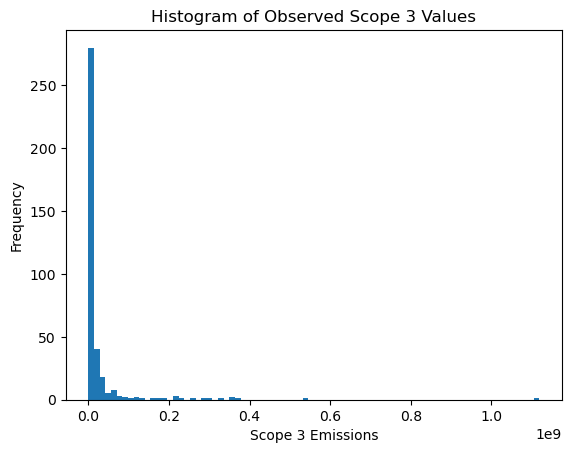

In [189]:

plt.hist(scope3_obs, bins=80)
plt.title("Histogram of Observed Scope 3 Values")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Frequency")
plt.show()


In [190]:
#print(f"Min: {scope3_obs.min()}, Max: {scope3_obs.max()}")


In [191]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
385,37844863.0,658617.0,1258232.0,NaN


In [192]:
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Sep 22           False
Price last day Sep 22            False
weight_in_sector                 False
float_mcap                       False
Scope 1                           True
Scope 2                           True
Scope 3                           True
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                  True
AnonID                            True
Manually Imputed Scope 2          True
Manually Imputed Scope 1          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Techno

In [193]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day Sep 22', 'float_mcap', 'Price last day Sep 22', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day Sep 22,float_mcap,Price last day Sep 22,Scope 1,Scope 2,Scope 3,Revenue
410,NEWS 'A',295387,5.971682e+06,15.11,12700.0,64000.0,866960.0,9879000.0
435,FOX A,280586,1.275490e+07,30.68,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',5503682,1.040530e+09,95.65,91200.0,8045400.0,10034000.0,307394000.0


In [194]:
len(gics)

500

In [195]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [196]:
len(gics)

500

In [197]:
gics.loc[gics['SYMBOL'].isin(['NWSA', 'FOXA', 'GOOGL']), ['NAME', 'ffnosh last day Sep 22', 'float_mcap', 'Price last day Sep 22', 'Scope 1', 'Scope 2', 'Scope 3', 'Revenue']]

,NAME,ffnosh last day Sep 22,float_mcap,Price last day Sep 22,Scope 1,Scope 2,Scope 3,Revenue
410,NEWS 'A',295387,5.971682e+06,15.11,12700.0,64000.0,866960.0,9879000.0
435,FOX A,280586,1.275490e+07,30.68,14266.0,52944.0,11877.0,14913000.0
490,ALPHABET 'A',5503682,1.040530e+09,95.65,91200.0,8045400.0,10034000.0,307394000.0


In [198]:

columns = ["Scope 1", "Scope 2", "Revenue", "float_mcap", "Carbon Intensity", "Scope 3"]
sector_columns = [col for col in gics.columns if col.startswith("Sector_")]
all_cols = columns + sector_columns
# Convert all boolean columns to int (0/1)
bool_cols = gics.select_dtypes(include='bool').columns
gics[bool_cols] = gics[bool_cols].astype(int)

# Subset the data
data = gics[all_cols].copy().reset_index(drop=True)
# Show all columns with object dtype
# Step 1: Get all object columns
object_cols = data.select_dtypes(include="object").columns

# Step 2: Convert them to float
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Initialize kernel (this builds multiple trees for imputation)
kernel = mf.ImputationKernel(
    data=data,
    num_datasets=3,
    mean_match_candidates=5,
    random_state=1
)

# Run MICE with PMM
kernel.mice(5)  # 5 iterations

# Extract imputed dataset
completed_data = kernel.complete_data(dataset=0)
# Identify missing Scope 3 values before imputation
missing_mask_original = gics["Scope 3"].isna() 
# Replace back into original
gics.reset_index(drop=True, inplace=True)
missing_mask = gics["Scope 3"].isna() 
gics.loc[gics['Scope 1'].isna(), "Scope 1 Imputed"] = 1
gics.loc[gics['Scope 2'].isna(), "Scope 2 Imputed"] = 1
gics.loc[gics['Scope 3'].isna(), "Scope 3 Imputed"] = 1


In [199]:
completed_data.iloc[387]

Scope 1                          1.136200e+04
Scope 2                          6.025700e+04
Revenue                          9.978000e+06
float_mcap                       3.286334e+07
Carbon Intensity                 1.114644e-01
Scope 3                          1.040573e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    0.000000e+00
Sector_Consumer Staples          0.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    1.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

In [200]:
gics.loc[gics['NAME'] == 'DOLLAR GENERAL', ['Revenue', 'Scope 1', 'Scope 2', 'Scope 3']]

,Revenue,Scope 1,Scope 2,Scope 3
385,37844863.0,658617.0,1258232.0,NaN


In [201]:
gics['Scope 1'] = completed_data["Scope 1"]
gics['Scope 2'] = completed_data["Scope 2"]
gics["Scope 3"] = completed_data["Scope 3"]

In [202]:
completed_data.iloc[387]

Scope 1                          1.136200e+04
Scope 2                          6.025700e+04
Revenue                          9.978000e+06
float_mcap                       3.286334e+07
Carbon Intensity                 1.114644e-01
Scope 3                          1.040573e+06
Sector_Communication Services    0.000000e+00
Sector_Consumer Discretionary    0.000000e+00
Sector_Consumer Staples          0.000000e+00
Sector_Energy                    0.000000e+00
Sector_Financials                0.000000e+00
Sector_Health Care               0.000000e+00
Sector_Industrials               0.000000e+00
Sector_Information Technology    1.000000e+00
Sector_Materials                 0.000000e+00
Sector_Real Estate               0.000000e+00
Sector_Utilities                 0.000000e+00
Name: 387, dtype: float64

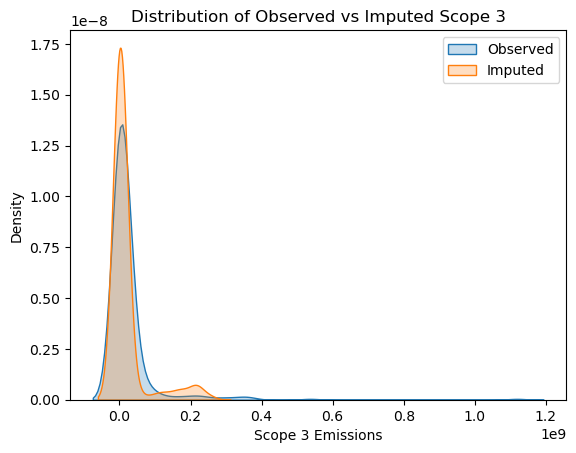

In [203]:
# Separate imputed and observed
imputed_values = gics.loc[missing_mask, "Scope 3"]
observed_values = gics.loc[~missing_mask, "Scope 3"]

# Plot
sns.kdeplot(observed_values, label="Observed", fill=True)
sns.kdeplot(imputed_values, label="Imputed", fill=True)
plt.title("Distribution of Observed vs Imputed Scope 3")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Density")
plt.legend()
plt.show()

- to do: calculate point to point deviation between observed scope 3 and predicted, could look at scatter plot by sector

In [204]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day Sep 22           False
Price last day Sep 22            False
weight_in_sector                 False
float_mcap                       False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
AnonID                            True
Manually Imputed Scope 2          True
Manually Imputed Scope 1          True
Manually Imputed Scope 3          True
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Techno

In [205]:
gics.loc[gics['GICS Sector'] == 'Communication Services']

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,weight_in_sector,float_mcap,Scope 1,Scope 2,...,Sector_Financials,Sector_Health Care,Sector_Industrials,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed
21,COMCAST A,981550,CMCSA,Communication Services,4559479,29.33,0.058193,1.337295e+08,496938.00,1480893.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
38,VERIZON COMMUNICATIONS,945384,VZ,Communication Services,3586061,37.97,0.059252,1.361627e+08,273904.00,3498643.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
49,TAKE TWO INTACT.SFTW.,889831,TTWO,Communication Services,100937,109,0.004788,1.100213e+07,1868.00,14892.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
98,WALT DISNEY,921964,DIS,Communication Services,1674943,94.33,0.068753,1.579974e+08,993347.00,782066.00,...,0,0,0,0,0,0,0,NaN,NaN,1.0
101,OMNICOM GROUP,932913,OMC,Communication Services,199213,63.09,0.005469,1.256835e+07,32915.00,34362.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
110,DISH NETWORK 'A' DEAD - DELIST.02/01/24,135448,DISH,Communication Services,249739,13.83,0.001503,3.453890e+06,10515.00,447908.00,...,0,0,0,0,0,0,0,1.0,1.0,1.0
113,ELECTRONIC ARTS,500320,EA,Communication Services,249861,115.71,0.012581,2.891142e+07,3875.00,19570.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
166,INTERPUBLIC GROUP,923465,IPG,Communication Services,341889,25.6,0.003809,8.752358e+06,11193.00,36553.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
203,ACTIVISION BLIZZARD DEAD - DELIST.16/10/23,312367,ATVI,Communication Services,722164,74.34,0.023361,5.368567e+07,2892.00,12309.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN
288,AT&T,945388,T,Communication Services,7126000,15.34,0.047568,1.093128e+08,917036.00,4962516.00,...,0,0,0,0,0,0,0,NaN,NaN,NaN


## 5) Recalculate weights in sector and market cap only for the sectors of CEG and OGN

In [206]:
gics_missing_sectors_name = gics.loc[gics['SYMBOL'].isin(['CEG']), 'GICS Sector']
gics = gics.loc[~gics['SYMBOL'].isin(['CEG'])]

In [207]:
gics_missing_sectors_name

457    Utilities
Name: GICS Sector, dtype: object

In [208]:
# STEP 0: Assume `gics` is your original DataFrame
# Columns: SYMBOL, ffnosh, Price, GICS Sector

gics_missing_sectors_filtered_df = gics.loc[gics['GICS Sector'].isin(gics_missing_sectors_name.values)]
print(gics_missing_sectors_filtered_df)
# STEP 1: Group by SYMBOL to combine share classes
aggregated = gics_missing_sectors_filtered_df.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'TYPE': df['TYPE'].iloc[0],
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day Sep 22'].sum(),
        'Weighted Price': (df['ffnosh last day Sep 22'] * df['Price last day Sep 22']).sum() / df['ffnosh last day Sep 22'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

                     NAME    TYPE SYMBOL GICS Sector ffnosh last day Sep 22  \
2                     AES  545101    AES   Utilities                 538382   
16         AMER.ELEC.PWR.  905425    AEP   Utilities                 483644   
27     PINNACLE WEST CAP.  902607    PNW   Utilities                  99186   
28                 AMEREN  670942    AEE   Utilities                 226738   
43            FIRSTENERGY  905159     FE   Utilities                 510055   
55                 SEMPRA  902103    SRE   Utilities                 522818   
81             NRG ENERGY  28179N    NRG   Utilities                 206813   
83    CONSOLIDATED EDISON  902288     ED   Utilities                 327192   
84             CMS ENERGY  901686    CMS   Utilities                 254906   
102            DTE ENERGY  905214    DTE   Utilities                 163638   
116          ATMOS ENERGY  511339    ATO   Utilities                 114311   
118               ENTERGY  902306    ETR   Utilities

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/2616253525.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics_missing_sectors_filtered_df.groupby('SYMBOL').apply(


In [209]:
len(aggregated)

28

In [210]:
gics.loc[gics['GICS Sector'].isin(gics_missing_sectors_name), ['weight_in_sector', 'float_mcap']] = np.nan

In [211]:
gics = pd.merge(gics, aggregated[['SYMBOL', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'SYMBOL', right_on = 'SYMBOL')

In [212]:
gics['weight_in_sector_x'] = gics['weight_in_sector_x'].fillna(gics['weight_in_sector_y'])
gics['float_mcap_x'] =  gics['float_mcap_x'].fillna(gics['float_mcap_y'])

In [213]:
gics['weight_in_sector'] = gics['weight_in_sector_x']
gics.drop(columns=['weight_in_sector_x', 'weight_in_sector_y'], inplace=True)

gics['float_mcap'] = gics['float_mcap_x']
gics.drop(columns=['float_mcap_x', 'float_mcap_y'], inplace=True)



In [214]:
len(gics)

499

In [215]:
gics.groupby(['GICS Sector'])['weight_in_sector'].sum()

GICS Sector
Communication Services    1.0
Consumer Discretionary    1.0
Consumer Staples          1.0
Energy                    1.0
Financials                1.0
Health Care               1.0
Industrials               1.0
Information Technology    1.0
Materials                 1.0
Real Estate               1.0
Utilities                 1.0
Name: weight_in_sector, dtype: float64

## 6) Fetch from Yahoo finance the adjusted price for corporate splits and dividends/capital gains (on LSEG is only adjusted for splits) -> to calculate covariance matrix

In [216]:
# # Define the tickers and date range
# tickers = list(gics['SYMBOL'].values) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close[tickers[0]] = data['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close[ticker] = data[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close.head())



9 Failed downloads:
['SBNY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30) (Yahoo error = "Data doesn\'t exist for startDate = 1575176400, endDate = 1672376400")')
['DISH', 'CTLT', 'WRK', 'ATVI', 'MRO', 'SIVBQ', 'PXD']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30)')


In [217]:
# #print(gics.loc[gics['SYMBOL'] == 'BF.B'])
# # Define the tickers and date range
# tickers = ['BF-B'] # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_bfb = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bfb = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bfb[tickers[0]] = data_bfb['BF-B']['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bfb[ticker] = data_bfb[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close_bfb.head())
# adj_close['BF.B'] = adj_close_bfb.values

In [218]:
# adj_close.to_excel("Data/adj_prices_yahoo_comp_1222.xlsm")

In [219]:
# adj_close = pd.read_excel("Data/adj_prices_yahoo_comp_1222.xlsm")
# adj_close.index = adj_close.Date
# adj_close.drop(columns='Date', inplace=True)

In [220]:
#len(set(gics['SYMBOL'].unique()) - set(adj_close.columns))

In [221]:
#len(set(adj_close.columns) - set(gics['SYMBOL'].unique()))

In [222]:
#adj_close = adj_close.drop(columns=set(adj_close.columns) - set(gics['SYMBOL'].unique()))

In [223]:
# # Define the tickers and date range
# tickers = list(set(gics['SYMBOL'].unique()) - set(adj_close.columns)) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_missing_yahoo = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_missing = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_missing[tickers[0]] = data_missing_yahoo[tickers]['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_missing[ticker] = data_missing_yahoo[ticker]['Adj Close']
#         except KeyError:
#             print(f"No data found for {ticker}.")

# # Display the result
# print(adj_close_missing.head())
# for ticker in tickers:
#     adj_close[ticker] = adj_close_missing[ticker].values

In [224]:
#set(gics['SYMBOL'].unique()) - set(adj_close.columns)

In [225]:
#adj_close.to_excel("Data/out-of-sample/adj_prices_yahoo_comp_0922.xlsm")

In [226]:
adj_close = pd.read_excel("Data/out-of-sample/adj_prices_yahoo_comp_0922.xlsm")
adj_close.index = adj_close.Date
adj_close.drop(columns='Date', inplace=True)

In [227]:
len(adj_close.columns)

500

In [228]:
adj_close['CEG']

Date
2021-09-30          NaN
2021-10-01          NaN
2021-10-04          NaN
2021-10-05          NaN
2021-10-06          NaN
                ...    
2022-10-26    86.692856
2022-10-27    90.852715
2022-10-28    91.546013
2022-10-31    92.317459
2022-11-01    93.274399
Name: CEG, Length: 275, dtype: float64

## 7) Fill in missing data from adjusted prices calculated manually or by refetching from Yahoo with the correct Symbol:

In [229]:
# suppose your DataFrame is called df
start = "2021-09-30"
end   = "2022-11-01"

adj_close = adj_close.loc[start:end]

In [230]:
price = pd.read_excel('Data/out-of-sample/price_div_comp_0922.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()

div_rate = pd.read_excel('Data/out-of-sample/price_div_comp_0922.xlsm', sheet_name='DIV RATE', header = 4)
div_rate.columns = div_rate.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip() 

div_date = pd.read_excel('Data/out-of-sample/price_div_comp_0922.xlsm', sheet_name='DIV DATE', header = 4)
div_date.columns = div_date.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()

div_date.columns = price.columns
div_rate.columns = price.columns

price.index = price.Code
div_rate.index = div_rate.Code
div_date.index = div_date.Code

price = price[start:end] 
div_rate = div_rate[start:end]
div_date = div_date[start:end] 

price = price.iloc[:, 1:]
div_rate = div_rate.iloc[:, 1:]
div_date = div_date.iloc[:, 1:]

# --- Step 1: Calculate adjustment factors
adj_factors = pd.DataFrame(1.0, index=price.index, columns=price.columns)

for company in price.columns:
    for i in range(1, len(price)):
        date = price.index[i]
        prev_date = price.index[i - 1]

        # If ex-dividend happens on this day
        if pd.notna(div_date.at[date, company]):
            div = div_rate.at[date, company]
            price_prev = price.at[prev_date, company]
            if price_prev and price_prev != 0:
                factor = (price_prev - div) / price_prev
                adj_factors.at[date, company] = factor

# --- Step 2: Calculate cumulative adjustment factors in reverse (like Yahoo)
cum_factors = adj_factors.iloc[::-1].cumprod().iloc[::-1]

# --- Step 3: Build adjusted prices
adjusted_prices_calculated = price * cum_factors


for stock in ['ABMD', 'DRE', 'CTXS', 'NLSN', 'TWTR', 'DISH', 'ATVI', 'PXD', 'SIVBQ', 'MRO', 'SBNY', 'CTLT', 'WRK']:
    type_stock_missing = gics.loc[gics['SYMBOL'] == stock, 'TYPE'].values
    print(adjusted_prices_calculated)
    adj_close[stock] = adjusted_prices_calculated.loc[adj_close.index,  type_stock_missing].values


              891399      916328     545101  777953      906187  936365  \
Code                                                                      
2021-09-30  164.2520  115.733599  22.071507  325.52  126.253380  102.90   
2021-10-01  164.1630  114.832263  22.139182  323.33  130.242842  102.45   
2021-10-04  159.4890  113.186343  22.081175  313.87  130.960683  100.34   
2021-10-05  161.0500  113.529243  22.603234  332.47  130.088333  101.81   
2021-10-06  163.1005  114.126869  22.641906  337.30  129.370397  103.64   
...              ...         ...        ...     ...         ...     ...   
2022-10-26  115.6600   98.420000  25.298031  268.25  135.010000   59.73   
2022-10-27  110.9600   96.930000  25.616120  267.58  134.770000   58.60   
2022-10-28  103.4100   99.490000  26.302000  258.06  138.510000   62.01   
2022-10-31  102.4400   98.940000  26.003791  252.08  138.290000   60.06   
2022-11-01   96.7900   99.310000  26.340000  377.82  138.200000   59.66   

              749382    

## 8) Calculate log monthly returns for past 2 years:

In [231]:
def calculate_log_monthly_returns(df):
    df = df.replace(0.0, np.nan).dropna(how="all")
    df_monthly = df.resample("M").last()
    df_monthly.index = df_monthly.index.map(lambda x: x.replace(day=15))
    log_returns = np.log(df_monthly).diff().dropna(how="all")
    return log_returns

In [232]:
dupes = adj_close.columns[adj_close.columns.duplicated()]
print(dupes)

Index([], dtype='object')


In [233]:
print(adj_close.shape)
print(adj_close.head())



(275, 500)
                  AMZN         ABT        AES         IBM         AMD  \
Date                                                                    
2021-09-30  164.251999  110.152802  19.851171  113.304756  102.900002   
2021-10-01  164.162994  109.294922  19.912043  116.885056  102.449997   
2021-10-04  159.488998  107.728371  19.859867  117.529327  100.339996   
2021-10-05  161.050003  108.054726  20.329412  116.746399  101.809998   
2021-10-06  163.100494  108.623535  20.364193  116.102127  103.639999   

                  ADBE         ARE         APD        ALK        BXP  ...  \
Date                                                                  ...   
2021-09-30  575.719971  166.246368  234.676895  58.599998  89.290771  ...   
2021-10-01  577.469971  168.821808  235.886429  62.200001  92.150391  ...   
2021-10-04  558.489990  168.917542  234.566925  62.090000  92.282234  ...   
2021-10-05  566.700012  167.168671  235.510727  61.599998  91.565262  ...   
2021-10-06  570

In [234]:
log_returns = calculate_log_monthly_returns(adj_close)

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_40851/3896427440.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").last()


In [235]:
cols_with_nans = adj_close.columns[adj_close.isna().any()]
print("Columns with NaNs:", cols_with_nans.tolist())

nan_columns = adj_close.loc[:, adj_close.isna().any(axis=0)]

for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO


Columns with NaNs: ['CEG']
First non-NaN in column 'CEG': 2022-01-19 00:00:00


In [236]:
from datetime import datetime
log_returns = log_returns.loc[log_returns.index > datetime(2021, 3, 15)]

In [237]:
for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    print(f"First non-NaN in column '{col}': {first_valid}") # these stocks had later IPO

First non-NaN in column 'CEG': 2022-01-19 00:00:00


In [238]:
gics['rank_in_sector'] = gics.groupby('GICS Sector')['weight_in_sector'].rank(ascending=False)

In [239]:
cols_with_nan = log_returns.columns[log_returns.isna().any()]
log_returns_nan = log_returns[cols_with_nan]
log_returns_nan

,CEG
Date,
2021-10-15,NaN
2021-11-15,NaN
2021-12-15,NaN
2022-01-15,NaN
2022-02-15,-0.039717
2022-03-15,0.201599
2022-04-15,0.051285
2022-05-15,0.049794
2022-06-15,-0.080822


In [240]:
gics

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day Sep 22,Price last day Sep 22,Scope 1,Scope 2,Scope 3,Revenue,...,Sector_Information Technology,Sector_Materials,Sector_Real Estate,Sector_Utilities,Scope 1 Imputed,Scope 2 Imputed,Scope 3 Imputed,weight_in_sector,float_mcap,rank_in_sector
0,AMAZON.COM,891399,AMZN,Consumer Discretionary,8504439,113,13020000.0,3060000.0,49020000.0,574785000.0,...,0,0,0,0,NaN,NaN,NaN,0.300450,9.610016e+08,1.0
1,ABBOTT LABORATORIES,916328,ABT,Health Care,1743574,96.76,530000.0,476000.0,12829000.0,40109000.0,...,0,0,0,0,NaN,NaN,NaN,0.039960,1.687082e+08,8.0
2,AES,545101,AES,Utilities,538382,22.6,39931000.0,479000.0,3118000.0,12668000.0,...,0,0,0,1,NaN,NaN,NaN,0.014723,1.216743e+07,23.0
3,ABIOMED DEAD - DELIST.23/12/22,777953,ABMD,Health Care,39185,245.66,27290000.0,3060000.0,217000000.0,847500000,...,0,0,0,0,1.0,1.0,1.0,0.002280,9.626187e+06,56.0
4,INTERNATIONAL BUS.MCHS.,906187,IBM,Information Technology,776410,118.81,79000.0,330000.0,586000.0,61860000.0,...,1,0,0,0,NaN,NaN,NaN,0.014327,9.224527e+07,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,WEC ENERGY GROUP,902335,WEC,Utilities,292206,89.43,18865000.0,231000.0,28348000.0,8893000.0,...,0,0,0,1,NaN,NaN,NaN,0.031621,2.613198e+07,10.0
495,MONSTER BEVERAGE,512785,MNST,Consumer Staples,745625,43.48,10077.0,8300.0,1854377.0,7140027.0,...,0,0,0,0,NaN,NaN,NaN,0.015343,3.241977e+07,18.0
496,LINDE (NYS),9373MH,LIN,Materials,494380,269.5901,16813000.0,20903000.0,25859001.0,32854000.0,...,0,1,0,0,NaN,NaN,NaN,0.185227,1.332800e+08,1.0
497,SBA COMMS.,699786,SBAC,Real Estate,101637,284.6499,11100.0,21000.0,53542.0,2711584.0,...,0,0,1,0,NaN,NaN,1.0,0.035301,2.893096e+07,8.0


In [241]:
set(gics.SYMBOL) - set(log_returns.columns)

set()

## 9) Calculate covariance by sector:

In [242]:
data = gics[['GICS Sector', 'SYMBOL', 'weight_in_sector', 'Carbon Intensity']] 
cols_with_nan = data.columns[data.isna().any()]
data_nan = data[cols_with_nan]

In [243]:
data_nan

""
0
1
2
3
4
...
494
495
496
497


In [244]:
# Create a dictionary to store covariance matrices by sector
sector_cov_matrices = {}
sector_log_returns = {}

# Loop over each unique GICS sector
for sector in data['GICS Sector'].unique():
    # Get list of symbols in this sector
    symbols_in_sector = data[(data['GICS Sector'] == sector)]['SYMBOL'].tolist()

    # Filter log_returns to only include columns (symbols) in this sector
    sector_returns = log_returns[symbols_in_sector]

    # Drop columns with all NaNs (in case any ticker has no returns)
    sector_returns = sector_returns.dropna(axis=1, how='all')

    # Calculate and store the covariance matrix
    if not sector_returns.empty:
        sector_log_returns[sector] = sector_returns.copy()
        sector_cov_matrices[sector] = sector_returns.cov()

# Optional: #print or inspect one example
example_sector = list(sector_cov_matrices.keys())[0]
#print(f"Covariance matrix for sector: {example_sector}")
#print(sector_cov_matrices[example_sector])

count_in_cov = 0
for key, value in sector_cov_matrices.items():
    count_in_cov += value.shape[0]
    #print(f"{key}: {value.shape}")
print(count_in_cov)
with pd.ExcelWriter("Data/out-of-sample/sector_cov_matrices_comp_0922.xlsx") as writer:
    for sector, cov_matrix in sector_cov_matrices.items():
        # Excel sheet names can't have certain characters or be too long
        safe_sector = sector[:31].replace('/', '_')
        cov_matrix.to_excel(writer, sheet_name=safe_sector)
with pd.ExcelWriter("Data/out-of-sample/sector_log_returns_comp_0922.xlsx") as writer:
    for sector, returns_df in sector_log_returns.items():
        safe_sector = sector[:31].replace('/', '_')
        returns_df.to_excel(writer, sheet_name=safe_sector)

499


In [245]:
count_in_cov

499

In [246]:
adj_close.to_excel("Data/out-of-sample/adj_price_yahoo_comp_0922.xlsx")

In [247]:
gics.to_excel("Data/out-of-sample/dataset_comp_0922.xlsx")